In [1]:
%pip -q install gradio torchmetrics
import os
import random
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchmetrics.functional import structural_similarity_index_measure as ssim
from torchmetrics.functional import peak_signal_noise_ratio as psnr

amp_device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(amp_device)
print('Device:', device)
if torch.cuda.is_available():
    print('GPU count:', torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f'GPU {i}: {torch.cuda.get_device_name(i)}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Note: you may need to restart the kernel to use updated packages.
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [4]:
@dataclass
class CFG:
    # Choose one: 'anime_concat' or 'cuhk_paired'
    DATASET_MODE = 'anime_concat'

    # Anime Sketch Colorization Pair (concatenated AB images in one file)
    ANIME_CONCAT_DIR = Path('/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train')

    # CUHK paired folders (set these if using cuhk_paired mode)
    CUHK_INPUT_DIR = Path('/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/sketch')
    CUHK_TARGET_DIR = Path('/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/photo')

    IMAGE_SIZE = 256  # can reduce to 128 if memory-limited
    BATCH_SIZE = 16   # assignment requires 16-32
    EPOCHS = 20
    LR = 2e-4
    BETAS = (0.5, 0.999)
    L1_LAMBDA = 100.0
    NUM_WORKERS = 2
    CHECKPOINT_EVERY = 5
    SUBSET_RATIO = 1.0
    FORCE_INPUT_GRAYSCALE = True
    OUTDIR = Path('/kaggle/working/q2_outputs')

CFG.OUTDIR.mkdir(parents=True, exist_ok=True)
print(CFG)

<class '__main__.CFG'>


In [5]:
class PairedImageDataset(Dataset):
    def __init__(self, input_dir, target_dir=None, image_size=256, subset_ratio=1.0, concat_pair_files=False, force_input_grayscale=True):
        self.input_dir = Path(input_dir)
        self.target_dir = Path(target_dir) if target_dir is not None else None
        self.concat_pair_files = concat_pair_files
        self.force_input_grayscale = force_input_grayscale
        exts = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

        if not self.input_dir.exists():
            raise FileNotFoundError(f'Input directory not found: {self.input_dir}')

        self.tfm_target = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])
        self.tfm_input = T.Compose([
            T.Resize((image_size, image_size)),
            T.Grayscale(num_output_channels=3) if force_input_grayscale else T.Lambda(lambda x: x),
            T.ToTensor(),
            T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])

        if self.concat_pair_files:
            files = [p for p in self.input_dir.rglob('*') if p.suffix.lower() in exts]
            if len(files) == 0:
                raise FileNotFoundError(f'No pair images found in: {self.input_dir}')
            random.shuffle(files)
            keep = max(1, int(len(files) * subset_ratio))
            self.files = files[:keep]
            self.pairs = None
            print(f'Pairing mode: concatenated AB files | samples: {len(self.files)}')
            print('Example file:', self.files[0].name)
        else:
            if self.target_dir is None or not self.target_dir.exists():
                raise FileNotFoundError(f'Target directory not found: {self.target_dir}')

            input_paths = [p for p in self.input_dir.rglob('*') if p.suffix.lower() in exts]
            target_paths = [p for p in self.target_dir.rglob('*') if p.suffix.lower() in exts]

            if len(input_paths) == 0:
                raise FileNotFoundError(f'No input images found in: {self.input_dir}')
            if len(target_paths) == 0:
                raise FileNotFoundError(f'No target images found in: {self.target_dir}')

            input_by_name = {p.name: p for p in input_paths}
            target_by_name = {p.name: p for p in target_paths}
            common_names = sorted(set(input_by_name).intersection(set(target_by_name)))

            if len(common_names) == 0:
                sample_in = [p.name for p in input_paths[:5]]
                sample_tg = [p.name for p in target_paths[:5]]
                raise FileNotFoundError(
                    'No exact filename pairs found. Use matching paired folders from one dataset split only. '
                    f'Input samples: {sample_in} | Target samples: {sample_tg}'
                )

            pairs = [(input_by_name[n], target_by_name[n]) for n in common_names]
            random.shuffle(pairs)
            keep = max(1, int(len(pairs) * subset_ratio))
            self.pairs = pairs[:keep]
            self.files = None
            print(f'Pairing mode: exact filename | pairs: {len(self.pairs)}')
            print('Example pair:', self.pairs[0][0].name, '->', self.pairs[0][1].name)

    def __len__(self):
        return len(self.files) if self.concat_pair_files else len(self.pairs)

    def __getitem__(self, idx):
        if self.concat_pair_files:
            img = Image.open(self.files[idx]).convert('RGB')
            w, h = img.size
            mid = w // 2
            if mid < 1:
                raise ValueError(f'Invalid pair image width for file: {self.files[idx]}')
            inp = img.crop((0, 0, mid, h))
            tgt = img.crop((mid, 0, w, h))
            x = self.tfm_input(inp)
            y = self.tfm_target(tgt)
            return x, y

        inp, tgt = self.pairs[idx]
        x = self.tfm_input(Image.open(inp).convert('RGB'))
        y = self.tfm_target(Image.open(tgt).convert('RGB'))
        return x, y

if CFG.DATASET_MODE == 'anime_concat':
    dataset = PairedImageDataset(
        CFG.ANIME_CONCAT_DIR,
        image_size=CFG.IMAGE_SIZE,
        subset_ratio=CFG.SUBSET_RATIO,
        concat_pair_files=True,
        force_input_grayscale=CFG.FORCE_INPUT_GRAYSCALE
    )
elif CFG.DATASET_MODE == 'cuhk_paired':
    dataset = PairedImageDataset(
        CFG.CUHK_INPUT_DIR, CFG.CUHK_TARGET_DIR,
        image_size=CFG.IMAGE_SIZE,
        subset_ratio=CFG.SUBSET_RATIO,
        concat_pair_files=False,
        force_input_grayscale=CFG.FORCE_INPUT_GRAYSCALE
    )
else:
    raise ValueError("CFG.DATASET_MODE must be 'anime_concat' or 'cuhk_paired'")

loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
                    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
print('Pairs/Samples:', len(dataset), 'Batches:', len(loader))

Pairing mode: concatenated AB files | samples: 14224
Example file: 1977001.png
Pairs/Samples: 14224 Batches: 889


In [6]:
def down_block(in_c, out_c, bn=True):
    layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
    if bn:
        layers.append(nn.BatchNorm2d(out_c))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)

def up_block(in_c, out_c, dropout=False):
    layers = [
        nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    ]
    if dropout:
        layers.append(nn.Dropout(0.5))
    return nn.Sequential(*layers)

class UNetGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3):
        super().__init__()
        self.d1 = down_block(in_ch, 64, bn=False)
        self.d2 = down_block(64, 128)
        self.d3 = down_block(128, 256)
        self.d4 = down_block(256, 512)
        self.d5 = down_block(512, 512)
        self.d6 = down_block(512, 512)
        self.d7 = down_block(512, 512)
        self.bottleneck = nn.Sequential(nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(True))

        self.u1 = up_block(512, 512, dropout=True)
        self.u2 = up_block(1024, 512, dropout=True)
        self.u3 = up_block(1024, 512, dropout=True)
        self.u4 = up_block(1024, 512)
        self.u5 = up_block(1024, 256)
        self.u6 = up_block(512, 128)
        self.u7 = up_block(256, 64)
        self.final = nn.Sequential(nn.ConvTranspose2d(128, out_ch, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1 = self.d1(x); d2 = self.d2(d1); d3 = self.d3(d2); d4 = self.d4(d3)
        d5 = self.d5(d4); d6 = self.d6(d5); d7 = self.d7(d6)
        b = self.bottleneck(d7)
        u1 = self.u1(b)
        u2 = self.u2(torch.cat([u1, d7], dim=1))
        u3 = self.u3(torch.cat([u2, d6], dim=1))
        u4 = self.u4(torch.cat([u3, d5], dim=1))
        u5 = self.u5(torch.cat([u4, d4], dim=1))
        u6 = self.u6(torch.cat([u5, d3], dim=1))
        u7 = self.u7(torch.cat([u6, d2], dim=1))
        return self.final(torch.cat([u7, d1], dim=1))

class PatchDiscriminator(nn.Module):
    # Configured to output a 16x16 probability map for 256x256 input
    def __init__(self, in_ch=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 3, 1, 1)
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

In [ ]:
G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)
optG = optim.Adam(G.parameters(), lr=CFG.LR, betas=CFG.BETAS)
optD = optim.Adam(D.parameters(), lr=CFG.LR, betas=CFG.BETAS)
adv_criterion = nn.BCEWithLogitsLoss()
l1_criterion = nn.L1Loss()
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

history = {'G_total': [], 'G_adv': [], 'G_l1': [], 'D_loss': []}

cfg_to_save = {}
for key, value in CFG.__dict__.items():
    if key.startswith('__'):
        continue
    cfg_to_save[key] = str(value) if isinstance(value, Path) else value

for epoch in range(1, CFG.EPOCHS + 1):
    g_total_run, g_adv_run, g_l1_run, d_run = 0.0, 0.0, 0.0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Discriminator
        optD.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=amp_device, enabled=torch.cuda.is_available()):
            fake = G(x).detach()
            d_real = D(x, y)
            d_fake = D(x, fake)
            real_lbl = torch.ones_like(d_real)
            fake_lbl = torch.zeros_like(d_fake)
            d_loss = 0.5 * (adv_criterion(d_real, real_lbl) + adv_criterion(d_fake, fake_lbl))
        scaler.scale(d_loss).backward()
        scaler.step(optD)

        # Generator
        optG.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=amp_device, enabled=torch.cuda.is_available()):
            fake = G(x)
            d_fake_for_g = D(x, fake)
            gan_loss = adv_criterion(d_fake_for_g, torch.ones_like(d_fake_for_g))
            rec_loss = l1_criterion(fake, y)
            g_loss = gan_loss + CFG.L1_LAMBDA * rec_loss
        scaler.scale(g_loss).backward()
        scaler.step(optG)
        scaler.update()

        g_total_run += g_loss.item()
        g_adv_run += gan_loss.item()
        g_l1_run += rec_loss.item()
        d_run += d_loss.item()

    history['G_total'].append(g_total_run / len(loader))
    history['G_adv'].append(g_adv_run / len(loader))
    history['G_l1'].append(g_l1_run / len(loader))
    history['D_loss'].append(d_run / len(loader))
    print(
        f'Epoch {epoch}/{CFG.EPOCHS} | '
        f'G_total: {history["G_total"][-1]:.4f} | '
        f'G_adv: {history["G_adv"][-1]:.4f} | '
        f'G_l1: {history["G_l1"][-1]:.4f} | '
        f'D: {history["D_loss"][-1]:.4f}'
    )

    if torch.cuda.is_available():
        print(f'GPU memory: {torch.cuda.memory_allocated()/(1024**3):.2f} GB')

    if epoch % CFG.CHECKPOINT_EVERY == 0:
        torch.save({
            'G': G.state_dict(),
            'D': D.state_dict(),
            'history': history,
            'cfg': cfg_to_save
        }, CFG.OUTDIR / f'pix2pix_ckpt_epoch_{epoch}.pt')

# Auto-save deployment checkpoint after full training
deploy_path = CFG.OUTDIR / 'pix2pix_generator_deploy.pt'
torch.save({
    'model_name': 'pix2pix_unet_generator',
    'generator_state_dict': G.state_dict(),
    'image_size': CFG.IMAGE_SIZE,
    'input_channels': 3,
    'output_channels': 3,
    'normalization': '[-1,1] with mean/std 0.5',
    'notes': 'Load UNetGenerator class with same architecture before state_dict loading.'
}, deploy_path)
print('Saved deployment checkpoint:', deploy_path)

Epoch 1/20 | G_total: 9.0718 | G_adv: 1.3135 | G_l1: 0.0776 | D: 0.5256
GPU memory: 0.88 GB
Epoch 2/20 | G_total: 5.9939 | G_adv: 1.7580 | G_l1: 0.0424 | D: 0.4615
GPU memory: 0.88 GB


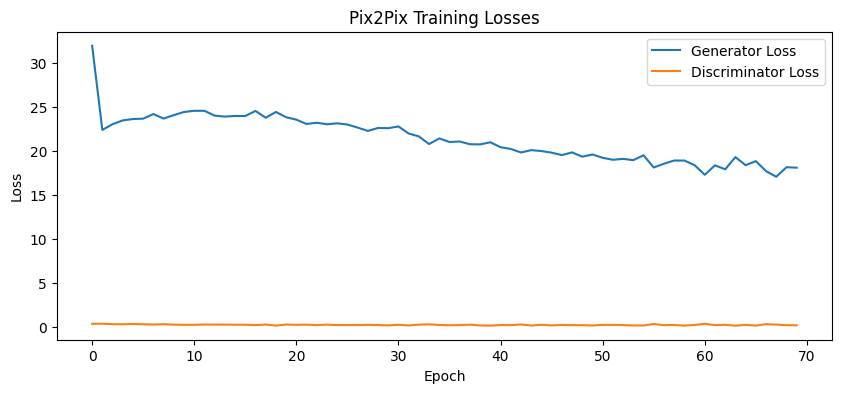

In [19]:
plt.figure(figsize=(10,4))
plt.plot(history['G_loss'], label='Generator Loss')
plt.plot(history['D_loss'], label='Discriminator Loss')
plt.title('Pix2Pix Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(history['G_total'], label='Generator Total Loss')
plt.plot(history['G_adv'], label='Generator Adversarial Loss')
plt.plot(history['G_l1'], label='Generator L1 Loss')
plt.plot(history['D_loss'], label='Discriminator Loss')
plt.title('Pix2Pix Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
@torch.no_grad()
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

@torch.no_grad()
def show_results(loader, n=8):
    G.eval()
    x, y = next(iter(loader))
    x, y = x[:n].to(device), y[:n].to(device)
    pred = G(x)

    x_v, y_v, p_v = denorm(x).cpu(), denorm(y).cpu(), denorm(pred).cpu()
    plt.figure(figsize=(14, n*2.5))
    for i in range(n):
        plt.subplot(n,3,3*i+1); plt.imshow(np.transpose(x_v[i].numpy(), (1,2,0))); plt.title('Input'); plt.axis('off')
        plt.subplot(n,3,3*i+2); plt.imshow(np.transpose(p_v[i].numpy(), (1,2,0))); plt.title('Generated'); plt.axis('off')
        plt.subplot(n,3,3*i+3); plt.imshow(np.transpose(y_v[i].numpy(), (1,2,0))); plt.title('Ground Truth'); plt.axis('off')
    plt.tight_layout(); plt.show()

    return pred, y

pred, gt = show_results(loader, n=6)
print('SSIM:', float(ssim(denorm(pred), denorm(gt), data_range=1.0)))
print('PSNR:', float(psnr(denorm(pred), denorm(gt), data_range=1.0)))